In [ ]:
from google.colab import files
uploaded = files.upload()


Saving Tyre Strat.xlsx to Tyre Strat.xlsx


In [ ]:
import pandas as pd
import io

df = pd.read_excel(io.BytesIO(uploaded['Tyre Strat.xlsx']))
df.head()


,Year,Race,Driver,Team,Grid Position,Finish Position,Position Change,Stint Number,Tyre,Start Lap,End Lap,Laps Used,Pit Stop After Stint
0,2019,German GP,Max Verstappen,Red Bull,2,1,1,1,WET,1,3,3,Yes
1,2019,German GP,Max Verstappen,Red Bull,2,1,1,2,INTERMEDIATE,4,25,22,Yes
2,2019,German GP,Max Verstappen,Red Bull,2,1,1,3,MEDIUM,26,29,4,Yes
3,2019,German GP,Max Verstappen,Red Bull,2,1,1,4,INTERMEDIATE,30,41,12,Yes
4,2019,German GP,Max Verstappen,Red Bull,2,1,1,5,INTERMEDIATE,42,46,5,Yes


In [ ]:

strategy = (
    df.groupby(["Year", "Race", "Driver", "Team"])
    .agg(
        Grid_Position=("Grid Position", "first"),
        Finish_Position=("Finish Position", "first"),
        Position_Change=("Position Change", "first"),
        Tyre_Changes=("Pit Stop After Stint", lambda x: (x == "Yes").sum()),
        First_Intermediate_Lap=("Start Lap", lambda x: df.loc[x.index][df.loc[x.index, "Tyre"] == "INTERMEDIATE"]["Start Lap"].min()),
        First_Wet_Lap=("Start Lap", lambda x: df.loc[x.index][df.loc[x.index, "Tyre"] == "WET"]["Start Lap"].min()),
        Intermediate_Laps=("Laps Used", lambda x: df.loc[x.index][df.loc[x.index, "Tyre"] == "INTERMEDIATE"]["Laps Used"].sum()),
        Wet_Laps=("Laps Used", lambda x: df.loc[x.index][df.loc[x.index, "Tyre"] == "WET"]["Laps Used"].sum()),
        Total_Laps=("Laps Used", "sum")
    )
    .reset_index()
)

strategy.head()


,Year,Race,Driver,Team,Grid_Position,Finish_Position,Position_Change,Tyre_Changes,First_Intermediate_Lap,First_Wet_Lap,Intermediate_Laps,Wet_Laps,Total_Laps
0,2019,German GP,Carlos Sainz,McLaren,7,5,2,3,4,1.0,61,3,64
1,2019,German GP,Daniil Kvyat,Toro Rosso,14,3,11,4,4,1.0,39,3,64
2,2019,German GP,Lance Stroll,Racing Point,15,4,11,5,8,1.0,34,7,64
3,2019,German GP,Lewis Hamilton,Mercedes,1,9,-8,6,4,1.0,43,3,64
4,2019,German GP,Max Verstappen,Red Bull,2,1,1,5,4,1.0,39,3,64


In [ ]:
strategy["Intermediate_Share"] = (
    strategy["Intermediate_Laps"] / strategy["Total_Laps"]
)

strategy["Wet_Share"] = (
    strategy["Wet_Laps"] / strategy["Total_Laps"])


In [ ]:
strategy = strategy.merge(
    weather_summary,
    on=["Year", "Race"],
    how="left"
)

strategy.head()


,Year,Race,Driver,Team,Grid_Position,Finish_Position,Position_Change,Tyre_Changes,First_Intermediate_Lap,First_Wet_Lap,Intermediate_Laps,Wet_Laps,Total_Laps,Total_Rain,Max_Hourly_Rain,Rain_Hours
0,2019,German GP,Carlos Sainz,McLaren,7,5,2,3,4,1.0,61,3,64,11.7,7.0,21
1,2019,German GP,Daniil Kvyat,Toro Rosso,14,3,11,4,4,1.0,39,3,64,11.7,7.0,21
2,2019,German GP,Lance Stroll,Racing Point,15,4,11,5,8,1.0,34,7,64,11.7,7.0,21
3,2019,German GP,Lewis Hamilton,Mercedes,1,9,-8,6,4,1.0,43,3,64,11.7,7.0,21
4,2019,German GP,Max Verstappen,Red Bull,2,1,1,5,4,1.0,39,3,64,11.7,7.0,21


In [ ]:
strategy[[
    "Race",
    "Driver",
    "Grid_Position",
    "Finish_Position",
    "Position_Change",
    "Tyre_Changes",
    "First_Intermediate_Lap",
    "Intermediate_Laps",
    "Intermediate_Share",
    "Total_Rain",
    "Rain_Hours"
]].sort_values(
    "Position_Change",
    ascending=False
).head(15)



,Race,Driver,Grid_Position,Finish_Position,Position_Change,Tyre_Changes,First_Intermediate_Lap,Intermediate_Laps,Intermediate_Share,Total_Rain,Rain_Hours
5,German GP,Sebastian Vettel,20,2,18,5,3,40,0.625000,11.7,21
1,German GP,Daniil Kvyat,14,3,11,4,4,39,0.609375,11.7,21
2,German GP,Lance Stroll,15,4,11,5,8,34,0.531250,11.7,21
16,Dutch GP,Pierre Gasly,12,3,9,5,2,22,0.305556,3.4,12
8,Emilia-Romagna GP,Lando Norris,7,3,4,2,1,28,0.444444,0.7,5
7,Emilia-Romagna GP,Kimi Raikkonen,16,13,3,3,1,26,0.412698,0.7,5
20,Monaco GP,George Russell,8,5,3,1,55,24,0.307692,6.9,9
17,Dutch GP,Sergio Perez,7,4,3,6,2,23,0.319444,3.4,12
14,Dutch GP,Fernando Alonso,5,2,3,5,3,19,0.263889,3.4,12
27,British GP,Max Verstappen,4,2,2,2,27,12,0.230769,2.0,8


In [ ]:
strategy[[
    "Position_Change",
    "First_Intermediate_Lap",
    "Intermediate_Laps",
    "Intermediate_Share",
    "Tyre_Changes"
]].corr()



,Position_Change,First_Intermediate_Lap,Intermediate_Laps,Intermediate_Share,Tyre_Changes
Position_Change,1.000000,-0.314380,0.282083,0.287293,0.185378
First_Intermediate_Lap,-0.314380,1.000000,-0.396694,-0.487316,-0.603699
Intermediate_Laps,0.282083,-0.396694,1.000000,0.978320,0.273379
Intermediate_Share,0.287293,-0.487316,0.978320,1.000000,0.269045
Tyre_Changes,0.185378,-0.603699,0.273379,0.269045,1.000000


In [ ]:
weather_strategy_corr = strategy[[
    "Total_Rain",
    "Max_Hourly_Rain",
    "Rain_Hours",
    "Position_Change",
    "First_Intermediate_Lap",
    "Intermediate_Laps",
    "Intermediate_Share",
    "Wet_Laps",
    "Wet_Share",
    "Tyre_Changes"
]].corr()

weather_strategy_corr


,Total_Rain,Max_Hourly_Rain,Rain_Hours,Position_Change,First_Intermediate_Lap,Intermediate_Laps,Intermediate_Share,Wet_Laps,Wet_Share,Tyre_Changes
Total_Rain,1.000000,0.984148,0.888194,0.321480,0.055626,0.733296,0.674746,0.239653,0.234591,0.275447
Max_Hourly_Rain,0.984148,1.000000,0.808887,0.300631,0.108732,0.742113,0.687093,0.254349,0.249971,0.143828
Rain_Hours,0.888194,0.808887,1.000000,0.374930,-0.260272,0.688094,0.680728,0.271680,0.265441,0.588032
Position_Change,0.321480,0.300631,0.374930,1.000000,-0.314380,0.282083,0.287293,0.132381,0.130234,0.185378
First_Intermediate_Lap,0.055626,0.108732,-0.260272,-0.314380,1.000000,-0.396694,-0.487316,-0.225147,-0.222136,-0.603699
Intermediate_Laps,0.733296,0.742113,0.688094,0.282083,-0.396694,1.000000,0.978320,0.179181,0.174888,0.273379
Intermediate_Share,0.674746,0.687093,0.680728,0.287293,-0.487316,0.978320,1.000000,0.205192,0.200930,0.269045
Wet_Laps,0.239653,0.254349,0.271680,0.132381,-0.225147,0.179181,0.205192,1.000000,0.999945,0.318507
Wet_Share,0.234591,0.249971,0.265441,0.130234,-0.222136,0.174888,0.200930,0.999945,1.000000,0.313696
Tyre_Changes,0.275447,0.143828,0.588032,0.185378,-0.603699,0.273379,0.269045,0.318507,0.313696,1.000000


In [ ]:
weather_strategy_corr["Position_Change"].sort_values(ascending=False)


,Position_Change
Position_Change,1.000000
Rain_Hours,0.374930
Total_Rain,0.321480
Max_Hourly_Rain,0.300631
Intermediate_Share,0.287293
Intermediate_Laps,0.282083
Tyre_Changes,0.185378
Wet_Laps,0.132381
Wet_Share,0.130234
First_Intermediate_Lap,-0.314380


In [ ]:
weather_strategy_corr["Intermediate_Share"].sort_values(ascending=False)

,Intermediate_Share
Intermediate_Share,1.000000
Intermediate_Laps,0.978320
Max_Hourly_Rain,0.687093
Rain_Hours,0.680728
Total_Rain,0.674746
Position_Change,0.287293
Tyre_Changes,0.269045
Wet_Laps,0.205192
Wet_Share,0.200930
First_Intermediate_Lap,-0.487316


In [ ]:
race_summary = (
    strategy
    .groupby(["Year", "Race"])
    .agg(
        Total_Rain=("Total_Rain", "first"),
        Max_Hourly_Rain=("Max_Hourly_Rain", "first"),
        Rain_Hours=("Rain_Hours", "first"),
        Avg_Position_Change=("Position_Change", "mean"),
        Avg_Intermediate_Share=("Intermediate_Share", "mean"),
        Avg_Wet_Share=("Wet_Share", "mean"),
        Avg_Tyre_Changes=("Tyre_Changes", "mean"),
        Max_Position_Gain=("Position_Change", "max")
    )
    .reset_index()
)

race_summary


,Year,Race,Total_Rain,Max_Hourly_Rain,Rain_Hours,Avg_Position_Change,Avg_Intermediate_Share,Avg_Wet_Share,Avg_Tyre_Changes,Max_Position_Gain
0,2019,German GP,11.7,7.0,21,5.833333,0.666667,0.054688,4.666667,18
1,2021,Emilia-Romagna GP,0.7,0.2,5,1.333333,0.394180,0.037037,2.833333,4
2,2023,Dutch GP,3.4,0.7,12,2.000000,0.263889,0.002315,5.166667,9
3,2023,Monaco GP,6.9,4.3,9,0.833333,0.301920,0.000000,1.666667,3
4,2024,British GP,2.0,0.7,8,0.833333,0.227564,0.000000,2.166667,2


In [ ]:
race_summary.sort_values(
    "Total_Rain",
    ascending=False
)


,Year,Race,Total_Rain,Max_Hourly_Rain,Rain_Hours,Avg_Position_Change,Avg_Intermediate_Share,Avg_Wet_Share,Avg_Tyre_Changes,Max_Position_Gain
0,2019,German GP,11.7,7.0,21,5.833333,0.666667,0.054688,4.666667,18
3,2023,Monaco GP,6.9,4.3,9,0.833333,0.301920,0.000000,1.666667,3
2,2023,Dutch GP,3.4,0.7,12,2.000000,0.263889,0.002315,5.166667,9
4,2024,British GP,2.0,0.7,8,0.833333,0.227564,0.000000,2.166667,2
1,2021,Emilia-Romagna GP,0.7,0.2,5,1.333333,0.394180,0.037037,2.833333,4


In [ ]:
# Top 10 position gains
top_gains = (
    strategy[[
        "Year",
        "Race",
        "Driver",
        "Team",
        "Grid_Position",
        "Finish_Position",
        "Position_Change",
        "Tyre_Changes",
        "First_Intermediate_Lap",
        "Intermediate_Laps",
        "Intermediate_Share",
        "Wet_Laps",
        "Wet_Share",
        "Total_Rain",
        "Max_Hourly_Rain",
        "Rain_Hours"
    ]]
    .sort_values("Position_Change", ascending=False)
    .head(10)
)

top_gains




,Year,Race,Driver,Team,Grid_Position,Finish_Position,Position_Change,Tyre_Changes,First_Intermediate_Lap,Intermediate_Laps,Intermediate_Share,Wet_Laps,Wet_Share,Total_Rain,Max_Hourly_Rain,Rain_Hours
5,2019,German GP,Sebastian Vettel,Ferrari,20,2,18,5,3,40,0.625000,2,0.031250,11.7,7.0,21
1,2019,German GP,Daniil Kvyat,Toro Rosso,14,3,11,4,4,39,0.609375,3,0.046875,11.7,7.0,21
2,2019,German GP,Lance Stroll,Racing Point,15,4,11,5,8,34,0.531250,7,0.109375,11.7,7.0,21
16,2023,Dutch GP,Pierre Gasly,Alpine,12,3,9,5,2,22,0.305556,0,0.000000,3.4,0.7,12
8,2021,Emilia-Romagna GP,Lando Norris,McLaren,7,3,4,2,1,28,0.444444,0,0.000000,0.7,0.2,5
7,2021,Emilia-Romagna GP,Kimi Raikkonen,Alfa Romeo,16,13,3,3,1,26,0.412698,0,0.000000,0.7,0.2,5
20,2023,Monaco GP,George Russell,Mercedes,8,5,3,1,55,24,0.307692,0,0.000000,6.9,4.3,9
17,2023,Dutch GP,Sergio Perez,Red Bull,7,4,3,6,2,23,0.319444,0,0.000000,3.4,0.7,12
14,2023,Dutch GP,Fernando Alonso,Aston Martin,5,2,3,5,3,19,0.263889,0,0.000000,3.4,0.7,12
27,2024,British GP,Max Verstappen,Red Bull,4,2,2,2,27,12,0.230769,0,0.000000,2.0,0.7,8


In [ ]:
# Worst position losses
worst_losses = (
    strategy[[
        "Year",
        "Race",
        "Driver",
        "Team",
        "Grid_Position",
        "Finish_Position",
        "Position_Change",
        "Tyre_Changes",
        "First_Intermediate_Lap",
        "Intermediate_Share",
        "Total_Rain",
        "Rain_Hours"
    ]]
    .sort_values("Position_Change", ascending=True)
    .head(10)
)

worst_losses


,Year,Race,Driver,Team,Grid_Position,Finish_Position,Position_Change,Tyre_Changes,First_Intermediate_Lap,Intermediate_Share,Total_Rain,Rain_Hours
3,2019,German GP,Lewis Hamilton,Mercedes,1,9,-8,6,4,0.671875,11.7,21
12,2023,Dutch GP,Alexander Albon,Williams,4,8,-4,4,62,0.152778,3.4,12
9,2021,Emilia-Romagna GP,Lewis Hamilton,Mercedes,1,2,-1,4,1,0.444444,0.7,5
6,2021,Emilia-Romagna GP,Charles Leclerc,Ferrari,4,4,0,2,1,0.444444,0.7,5
11,2021,Emilia-Romagna GP,Pierre Gasly,AlphaTauri,5,5,0,4,15,0.190476,0.7,5
15,2023,Dutch GP,Max Verstappen,Red Bull,1,1,0,6,3,0.263889,3.4,12
18,2023,Monaco GP,Esteban Ocon,Alpine,3,3,0,2,55,0.307692,6.9,9
19,2023,Monaco GP,Fernando Alonso,Aston Martin,2,2,0,2,56,0.294872,6.9,9
25,2024,British GP,Lando Norris,McLaren,3,3,0,2,28,0.230769,2.0,8
23,2023,Monaco GP,Max Verstappen,Red Bull,1,1,0,1,56,0.294872,6.9,9


In [ ]:
# Strategy vs position gain
strategy[[
    "Position_Change",
    "First_Intermediate_Lap",
    "Intermediate_Share",
    "Wet_Share",
    "Tyre_Changes"
]].corr()["Position_Change"].sort_values(ascending=False)


,Position_Change
Position_Change,1.000000
Intermediate_Share,0.287293
Tyre_Changes,0.185378
Wet_Share,0.130234
First_Intermediate_Lap,-0.314380


In [ ]:
race_summary[[
    "Year",
    "Race",
    "Total_Rain",
    "Max_Hourly_Rain",
    "Rain_Hours",
    "Avg_Position_Change",
    "Avg_Intermediate_Share",
    "Avg_Wet_Share",
    "Avg_Tyre_Changes",
    "Max_Position_Gain"
]].sort_values(
    "Total_Rain",
    ascending=False
)


,Year,Race,Total_Rain,Max_Hourly_Rain,Rain_Hours,Avg_Position_Change,Avg_Intermediate_Share,Avg_Wet_Share,Avg_Tyre_Changes,Max_Position_Gain
0,2019,German GP,11.7,7.0,21,5.833333,0.666667,0.054688,4.666667,18
3,2023,Monaco GP,6.9,4.3,9,0.833333,0.301920,0.000000,1.666667,3
2,2023,Dutch GP,3.4,0.7,12,2.000000,0.263889,0.002315,5.166667,9
4,2024,British GP,2.0,0.7,8,0.833333,0.227564,0.000000,2.166667,2
1,2021,Emilia-Romagna GP,0.7,0.2,5,1.333333,0.394180,0.037037,2.833333,4


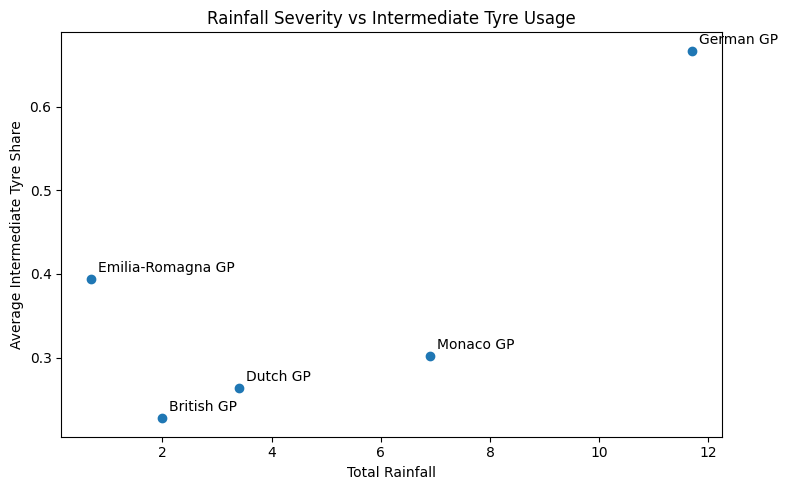

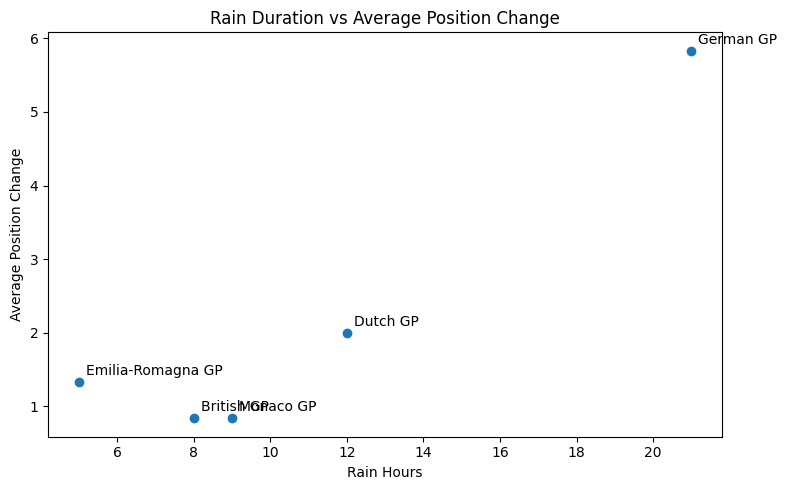

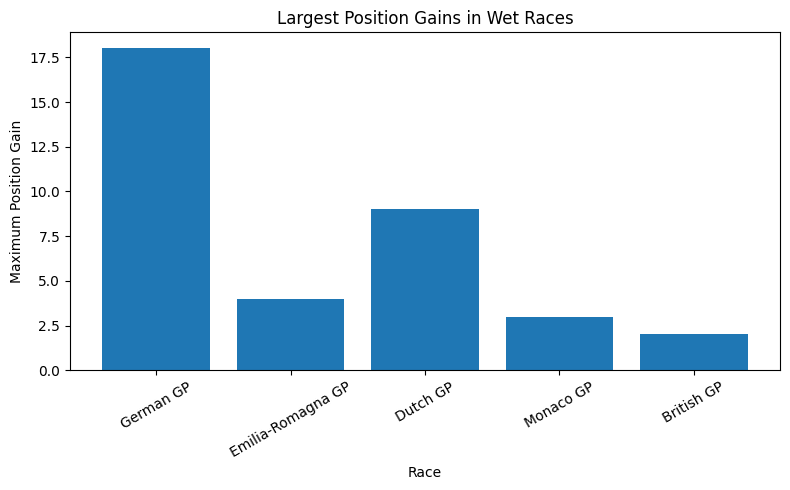

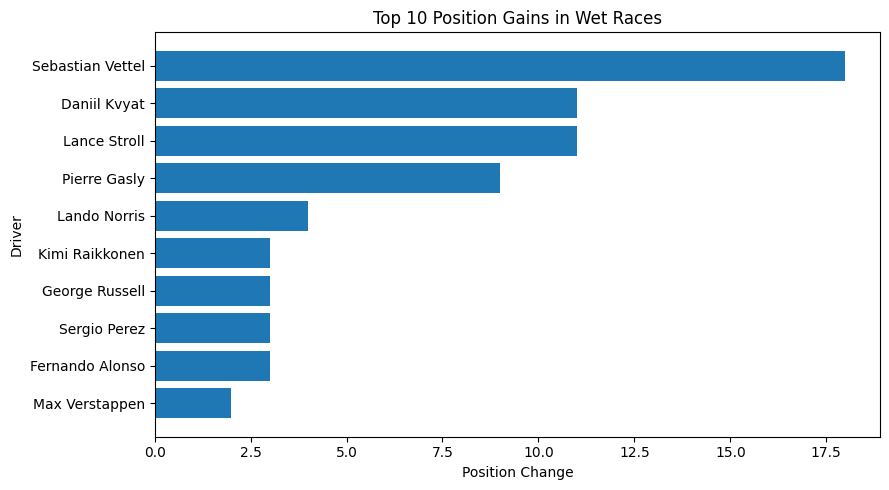

In [ ]:

import matplotlib.pyplot as plt

# 1. Rainfall vs Intermediate Tyre Usage
plt.figure(figsize=(8, 5))
plt.scatter(
    race_summary["Total_Rain"],
    race_summary["Avg_Intermediate_Share"]
)

for _, row in race_summary.iterrows():
    plt.annotate(
        row["Race"],
        (row["Total_Rain"], row["Avg_Intermediate_Share"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Total Rainfall")
plt.ylabel("Average Intermediate Tyre Share")
plt.title("Rainfall Severity vs Intermediate Tyre Usage")
plt.tight_layout()
plt.show()


# 2. Rain Hours vs Average Position Change
plt.figure(figsize=(8, 5))
plt.scatter(
    race_summary["Rain_Hours"],
    race_summary["Avg_Position_Change"]
)

for _, row in race_summary.iterrows():
    plt.annotate(
        row["Race"],
        (row["Rain_Hours"], row["Avg_Position_Change"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Rain Hours")
plt.ylabel("Average Position Change")
plt.title("Rain Duration vs Average Position Change")
plt.tight_layout()
plt.show()


# 3. Maximum Position Gain by Race
plt.figure(figsize=(8, 5))
plt.bar(
    race_summary["Race"],
    race_summary["Max_Position_Gain"]
)

plt.xlabel("Race")
plt.ylabel("Maximum Position Gain")
plt.title("Largest Position Gains in Wet Races")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# 4. Top 10 Drivers by Position Gain
top10 = strategy.sort_values(
    "Position_Change",
    ascending=False
).head(10)

plt.figure(figsize=(9, 5))
plt.barh(
    top10["Driver"],
    top10["Position_Change"]
)

plt.xlabel("Position Change")
plt.ylabel("Driver")
plt.title("Top 10 Position Gains in Wet Races")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [ ]:
import sqlite3

conn = sqlite3.connect("f1_wet_weather.db")

cursor = conn.cursor()

cursor.execute("""
DROP TABLE IF EXISTS race_strategy
""")

cursor.execute("""
DROP TABLE IF EXISTS races
""")

cursor.execute("""
CREATE TABLE races (
    Year INTEGER,
    Race TEXT,
    Total_Rain REAL,
    Max_Hourly_Rain REAL,
    Rain_Hours INTEGER,
    PRIMARY KEY (Year, Race)
)
""")

cursor.execute("""
CREATE TABLE race_strategy (
    Year INTEGER,
    Race TEXT,
    Driver TEXT,
    Team TEXT,
    Grid_Position INTEGER,
    Finish_Position INTEGER,
    Position_Change INTEGER,
    Tyre_Changes INTEGER,
    First_Intermediate_Lap REAL,
    First_Wet_Lap REAL,
    Intermediate_Laps INTEGER,
    Wet_Laps INTEGER,
    Total_Laps INTEGER,
    Intermediate_Share REAL,
    Wet_Share REAL,
    FOREIGN KEY (Year, Race) REFERENCES races(Year, Race)
)
""")

conn.commit()


In [ ]:

races = strategy[
    [
        "Year",
        "Race",
        "Total_Rain",
        "Max_Hourly_Rain",
        "Rain_Hours"
    ]
].drop_duplicates()

races.to_sql(
    "races",
    conn,
    if_exists="append",
    index=False
)

race_strategy = strategy[
    [
        "Year",
        "Race",
        "Driver",
        "Team",
        "Grid_Position",
        "Finish_Position",
        "Position_Change",
        "Tyre_Changes",
        "First_Intermediate_Lap",
        "First_Wet_Lap",
        "Intermediate_Laps",
        "Wet_Laps",
        "Total_Laps",
        "Intermediate_Share",
        "Wet_Share"
    ]
]

race_strategy.to_sql(
    "race_strategy",
    conn,
    if_exists="append",
    index=False
)

conn.commit()


In [ ]:
pd.read_sql_query(
    "SELECT * FROM races",
    conn
)


,Year,Race,Total_Rain,Max_Hourly_Rain,Rain_Hours
0,2019,German GP,11.7,7.0,21
1,2021,Emilia-Romagna GP,0.7,0.2,5
2,2023,Dutch GP,3.4,0.7,12
3,2023,Monaco GP,6.9,4.3,9
4,2024,British GP,2.0,0.7,8


In [ ]:
pd.read_sql_query(
    "SELECT * FROM race_strategy LIMIT 10",
    conn
)


,Year,Race,Driver,Team,Grid_Position,Finish_Position,Position_Change,Tyre_Changes,First_Intermediate_Lap,First_Wet_Lap,Intermediate_Laps,Wet_Laps,Total_Laps,Intermediate_Share,Wet_Share
0,2019,German GP,Carlos Sainz,McLaren,7,5,2,3,4.0,1.0,61,3,64,0.953125,0.046875
1,2019,German GP,Daniil Kvyat,Toro Rosso,14,3,11,4,4.0,1.0,39,3,64,0.609375,0.046875
2,2019,German GP,Lance Stroll,Racing Point,15,4,11,5,8.0,1.0,34,7,64,0.531250,0.109375
3,2019,German GP,Lewis Hamilton,Mercedes,1,9,-8,6,4.0,1.0,43,3,64,0.671875,0.046875
4,2019,German GP,Max Verstappen,Red Bull,2,1,1,5,4.0,1.0,39,3,64,0.609375,0.046875
5,2019,German GP,Sebastian Vettel,Ferrari,20,2,18,5,3.0,1.0,40,2,64,0.625000,0.031250
6,2021,Emilia-Romagna GP,Charles Leclerc,Ferrari,4,4,0,2,1.0,NaN,28,0,63,0.444444,0.000000
7,2021,Emilia-Romagna GP,Kimi Raikkonen,Alfa Romeo,16,13,3,3,1.0,NaN,26,0,63,0.412698,0.000000
8,2021,Emilia-Romagna GP,Lando Norris,McLaren,7,3,4,2,1.0,NaN,28,0,63,0.444444,0.000000
9,2021,Emilia-Romagna GP,Lewis Hamilton,Mercedes,1,2,-1,4,1.0,NaN,28,0,63,0.444444,0.000000


In [ ]:
query = """
SELECT
    Year,
    Race,
    Driver,
    Team,
    Grid_Position,
    Finish_Position,
    Position_Change
FROM race_strategy
ORDER BY Position_Change DESC
LIMIT 10;
"""

q1 = pd.read_sql_query(query, conn)
q1


,Year,Race,Driver,Team,Grid_Position,Finish_Position,Position_Change
0,2019,German GP,Sebastian Vettel,Ferrari,20,2,18
1,2019,German GP,Daniil Kvyat,Toro Rosso,14,3,11
2,2019,German GP,Lance Stroll,Racing Point,15,4,11
3,2023,Dutch GP,Pierre Gasly,Alpine,12,3,9
4,2021,Emilia-Romagna GP,Lando Norris,McLaren,7,3,4
5,2021,Emilia-Romagna GP,Kimi Raikkonen,Alfa Romeo,16,13,3
6,2023,Dutch GP,Fernando Alonso,Aston Martin,5,2,3
7,2023,Dutch GP,Sergio Perez,Red Bull,7,4,3
8,2023,Monaco GP,George Russell,Mercedes,8,5,3
9,2019,German GP,Carlos Sainz,McLaren,7,5,2


In [ ]:
query = """
SELECT
    Year,
    Race,
    Total_Rain,
    Max_Hourly_Rain,
    Rain_Hours
FROM races
ORDER BY Total_Rain DESC;
"""

q2 = pd.read_sql_query(query, conn)
q2


,Year,Race,Total_Rain,Max_Hourly_Rain,Rain_Hours
0,2019,German GP,11.7,7.0,21
1,2023,Monaco GP,6.9,4.3,9
2,2023,Dutch GP,3.4,0.7,12
3,2024,British GP,2.0,0.7,8
4,2021,Emilia-Romagna GP,0.7,0.2,5


In [ ]:
query = """
SELECT
    rs.Year,
    rs.Race,
    rs.Driver,
    rs.Team,
    r.Total_Rain,
    r.Rain_Hours,
    rs.Intermediate_Share,
    rs.Tyre_Changes,
    rs.Position_Change
FROM race_strategy rs
JOIN races r
    ON rs.Year = r.Year
    AND rs.Race = r.Race
ORDER BY rs.Position_Change DESC;
"""

q3 = pd.read_sql_query(query, conn)
q3.head(15)


,Year,Race,Driver,Team,Total_Rain,Rain_Hours,Intermediate_Share,Tyre_Changes,Position_Change
0,2019,German GP,Sebastian Vettel,Ferrari,11.7,21,0.625000,5,18
1,2019,German GP,Daniil Kvyat,Toro Rosso,11.7,21,0.609375,4,11
2,2019,German GP,Lance Stroll,Racing Point,11.7,21,0.531250,5,11
3,2023,Dutch GP,Pierre Gasly,Alpine,3.4,12,0.305556,5,9
4,2021,Emilia-Romagna GP,Lando Norris,McLaren,0.7,5,0.444444,2,4
5,2021,Emilia-Romagna GP,Kimi Raikkonen,Alfa Romeo,0.7,5,0.412698,3,3
6,2023,Dutch GP,Fernando Alonso,Aston Martin,3.4,12,0.263889,5,3
7,2023,Dutch GP,Sergio Perez,Red Bull,3.4,12,0.319444,6,3
8,2023,Monaco GP,George Russell,Mercedes,6.9,9,0.307692,1,3
9,2019,German GP,Carlos Sainz,McLaren,11.7,21,0.953125,3,2


In [ ]:
query = """
SELECT
    r.Year,
    r.Race,
    r.Total_Rain,
    r.Rain_Hours,
    ROUND(AVG(rs.Intermediate_Share), 3) AS Avg_Intermediate_Share,
    ROUND(AVG(rs.Tyre_Changes), 2) AS Avg_Tyre_Changes,
    ROUND(AVG(rs.Position_Change), 2) AS Avg_Position_Change,
    MAX(rs.Position_Change) AS Max_Position_Gain
FROM races r
JOIN race_strategy rs
    ON r.Year = rs.Year
    AND r.Race = rs.Race
GROUP BY
    r.Year,
    r.Race
ORDER BY r.Total_Rain DESC;
"""

q4 = pd.read_sql_query(query, conn)
q4



,Year,Race,Total_Rain,Rain_Hours,Avg_Intermediate_Share,Avg_Tyre_Changes,Avg_Position_Change,Max_Position_Gain
0,2019,German GP,11.7,21,0.667,4.67,5.83,18
1,2023,Monaco GP,6.9,9,0.302,1.67,0.83,3
2,2023,Dutch GP,3.4,12,0.264,5.17,2.00,9
3,2024,British GP,2.0,8,0.228,2.17,0.83,2
4,2021,Emilia-Romagna GP,0.7,5,0.394,2.83,1.33,4


In [ ]:
query = """
SELECT
    rs.Year,
    rs.Race,
    rs.Driver,
    rs.Team,
    r.Total_Rain,
    r.Rain_Hours,
    rs.Position_Change,
    ROUND(rs.Intermediate_Share, 3) AS Intermediate_Share
FROM race_strategy rs
JOIN races r
    ON rs.Year = r.Year
    AND rs.Race = r.Race
WHERE r.Total_Rain > 5
  AND rs.Position_Change > 0
ORDER BY rs.Position_Change DESC;
"""

q5 = pd.read_sql_query(query, conn)
q5


,Year,Race,Driver,Team,Total_Rain,Rain_Hours,Position_Change,Intermediate_Share
0,2019,German GP,Sebastian Vettel,Ferrari,11.7,21,18,0.625
1,2019,German GP,Daniil Kvyat,Toro Rosso,11.7,21,11,0.609
2,2019,German GP,Lance Stroll,Racing Point,11.7,21,11,0.531
3,2023,Monaco GP,George Russell,Mercedes,6.9,9,3,0.308
4,2019,German GP,Carlos Sainz,McLaren,11.7,21,2,0.953
5,2019,German GP,Max Verstappen,Red Bull,11.7,21,1,0.609
6,2023,Monaco GP,Lando Norris,McLaren,6.9,9,1,0.299
7,2023,Monaco GP,Lewis Hamilton,Mercedes,6.9,9,1,0.308


In [ ]:
query = """
SELECT
    Driver,
    COUNT(*) AS Races,
    ROUND(AVG(Intermediate_Share), 3) AS Avg_Intermediate_Share,
    ROUND(AVG(Tyre_Changes), 2) AS Avg_Tyre_Changes,
    ROUND(AVG(Position_Change), 2) AS Avg_Position_Change,
    MAX(Position_Change) AS Best_Position_Gain
FROM race_strategy
GROUP BY Driver
HAVING COUNT(*) >= 2
ORDER BY Avg_Position_Change DESC;
"""

q6 = pd.read_sql_query(query, conn)
q6


,Driver,Races,Avg_Intermediate_Share,Avg_Tyre_Changes,Avg_Position_Change,Best_Position_Gain
0,Pierre Gasly,2,0.248,4.50,4.50,9
1,Lando Norris,3,0.325,2.00,1.67,4
2,Carlos Sainz,3,0.494,3.67,1.67,2
3,Fernando Alonso,2,0.279,3.50,1.50,3
4,Max Verstappen,5,0.365,3.20,1.00,2
5,Lewis Hamilton,4,0.409,3.50,-2.00,1


In [ ]:
query = """
WITH driver_strategy AS (
    SELECT
        Driver,
        Race,
        Position_Change,
        Intermediate_Share
    FROM race_strategy
)
SELECT
    Driver,
    Race,
    ROUND(Intermediate_Share, 3) AS Intermediate_Share,
    Position_Change
FROM driver_strategy
WHERE Intermediate_Share >= 0.30
  AND Position_Change > 0
ORDER BY Position_Change DESC;
"""

q7 = pd.read_sql_query(query, conn)
q7


,Driver,Race,Intermediate_Share,Position_Change
0,Sebastian Vettel,German GP,0.625,18
1,Daniil Kvyat,German GP,0.609,11
2,Lance Stroll,German GP,0.531,11
3,Pierre Gasly,Dutch GP,0.306,9
4,Lando Norris,Emilia-Romagna GP,0.444,4
5,Kimi Raikkonen,Emilia-Romagna GP,0.413,3
6,Sergio Perez,Dutch GP,0.319,3
7,George Russell,Monaco GP,0.308,3
8,Carlos Sainz,German GP,0.953,2
9,Max Verstappen,Emilia-Romagna GP,0.429,2


In [ ]:
sql_code = """
-- F1 Wet Weather Analysis
-- SQL Analysis Queries


-- Query 1: Top 10 position gains

SELECT
    Year,
    Race,
    Driver,
    Team,
    Grid_Position,
    Finish_Position,
    Position_Change
FROM race_strategy
ORDER BY Position_Change DESC
LIMIT 10;


-- Query 2: Races ranked by rainfall

SELECT
    Year,
    Race,
    Total_Rain,
    Max_Hourly_Rain,
    Rain_Hours
FROM races
ORDER BY Total_Rain DESC;


-- Query 3: Rainfall and driver strategy

SELECT
    rs.Year,
    rs.Race,
    rs.Driver,
    rs.Team,
    r.Total_Rain,
    r.Rain_Hours,
    rs.Intermediate_Share,
    rs.Tyre_Changes,
    rs.Position_Change
FROM race_strategy rs
JOIN races r
    ON rs.Year = r.Year
    AND rs.Race = r.Race
ORDER BY rs.Position_Change DESC;


-- Query 4: Race-level strategy and performance

SELECT
    r.Year,
    r.Race,
    r.Total_Rain,
    r.Rain_Hours,
    ROUND(AVG(rs.Intermediate_Share), 3) AS Avg_Intermediate_Share,
    ROUND(AVG(rs.Tyre_Changes), 2) AS Avg_Tyre_Changes,
    ROUND(AVG(rs.Position_Change), 2) AS Avg_Position_Change,
    MAX(rs.Position_Change) AS Max_Position_Gain
FROM races r
JOIN race_strategy rs
    ON r.Year = rs.Year
    AND r.Race = rs.Race
GROUP BY
    r.Year,
    r.Race
ORDER BY r.Total_Rain DESC;


-- Query 5: Position gains in heavy rain

SELECT
    rs.Year,
    rs.Race,
    rs.Driver,
    rs.Team,
    r.Total_Rain,
    r.Rain_Hours,
    rs.Position_Change,
    ROUND(rs.Intermediate_Share, 3) AS Intermediate_Share
FROM race_strategy rs
JOIN races r
    ON rs.Year = r.Year
    AND rs.Race = r.Race
WHERE r.Total_Rain > 5
  AND rs.Position_Change > 0
ORDER BY rs.Position_Change DESC;


-- Query 6: Driver performance across multiple wet races

SELECT
    Driver,
    COUNT(*) AS Races,
    ROUND(AVG(Intermediate_Share), 3) AS Avg_Intermediate_Share,
    ROUND(AVG(Tyre_Changes), 2) AS Avg_Tyre_Changes,
    ROUND(AVG(Position_Change), 2) AS Avg_Position_Change,
    MAX(Position_Change) AS Best_Position_Gain
FROM race_strategy
GROUP BY Driver
HAVING COUNT(*) >= 2
ORDER BY Avg_Position_Change DESC;


-- Query 7: Drivers gaining positions with significant intermediate usage

WITH driver_strategy AS (
    SELECT
        Driver,
        Race,
        Position_Change,
        Intermediate_Share
    FROM race_strategy
)
SELECT
    Driver,
    Race,
    ROUND(Intermediate_Share, 3) AS Intermediate_Share,
    Position_Change
FROM driver_strategy
WHERE Intermediate_Share >= 0.30
  AND Position_Change > 0
ORDER BY Position_Change DESC;
"""

with open("analysis_queries.sql", "w") as file:
    file.write(sql_code)

print("analysis_queries.sql created successfully!")


analysis_queries.sql created successfully!


In [ ]:
# Export SQL tables for Power BI

races_powerbi = pd.read_sql_query(
    "SELECT * FROM races",
    conn
)

strategy_powerbi = pd.read_sql_query(
    "SELECT * FROM race_strategy",
    conn
)

races_powerbi.to_csv("races_powerbi.csv", index=False)
strategy_powerbi.to_csv("strategy_powerbi.csv", index=False)

print("Power BI files created!")


Power BI files created!
